In [1]:
# SETUPs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.linear_model import Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from joblib import Parallel, delayed
from simulation_ml import (
    generate_single_dataset,
    evaluate_learners,
)
from simulation_inference_ml_ALL import (
    generate_dataset_with_known_beta,
    estimate_partial_effect,
    run_single_simulation,
)


Generating data (n=300, p=500)...
Running Cross-Validation for Hyperparameter Tuning...

Comparison of Learners (Out-of-sample MSE):
     Learner      MSE
         OLS 3.271496
       Lasso 1.117134
  ElasticNet 1.116718
RandomForest 1.167915
      GBoost 1.111926

Best parameters for OLS: None

Best parameters for Lasso: {'model__alpha': np.float64(0.05994842503189409)}

Best parameters for ElasticNet: {'model__alpha': np.float64(0.21544346900318845), 'model__l1_ratio': 0.5}

Best parameters for Random Forest: {'model__max_depth': 10, 'model__min_samples_leaf': 5}

Best parameters for Gradient Boosting: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}


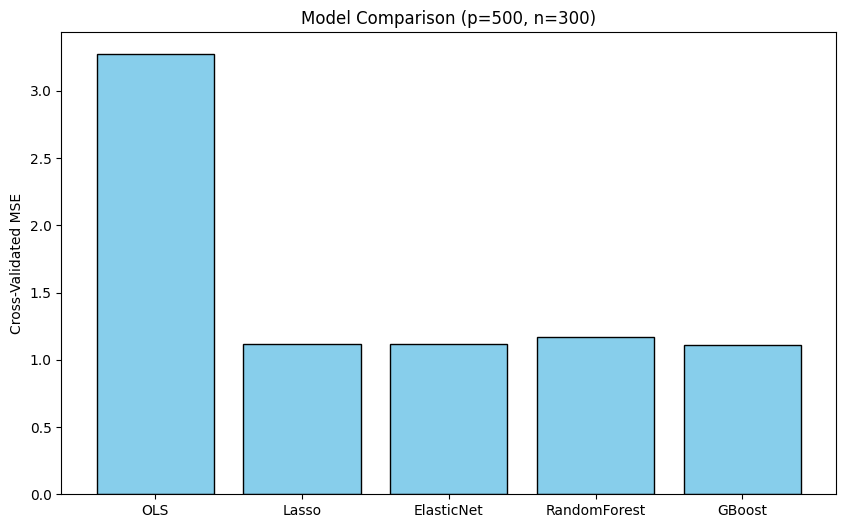

In [2]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

n = 300
p = 500  # High-dimensional case p > n
sigma = 1.0
print(f"Generating data (n={n}, p={p})...")
X, Y = generate_single_dataset(n, p, sigma)
print("Running Cross-Validation for Hyperparameter Tuning...")
df_results = evaluate_learners(X, Y)
# Print Results Table
print("\nComparison of Learners (Out-of-sample MSE):")
print(df_results[["Learner", "MSE"]].to_string(index=False))
# Save visualization
plt.figure(figsize=(10, 6))
plt.bar(df_results["Learner"], df_results["MSE"], color='skyblue', edgecolor='black')
plt.ylabel("Cross-Validated MSE")
plt.title(f"Model Comparison (p={p}, n={n})")
plt.savefig(FIGURES_DIR / "learner_comparison_cv.png", dpi=300)

print(f"\nBest parameters for OLS: {df_results.iloc[0]['Params']}")
print(f"\nBest parameters for Lasso: {df_results.iloc[1]['Params']}") # Best alpha for Lasso
print(f"\nBest parameters for ElasticNet: {df_results.iloc[2]['Params']}") # Best alpha and l1_ratio for ElasticNet
print(f"\nBest parameters for Random Forest: {df_results.iloc[3]['Params']}") # Best max_depth and min_samples_leaf for Random Forest
print(f"\nBest parameters for Gradient Boosting: {df_results.iloc[4]['Params']}") # Best n_estimators, learning_rate, max_depth for Gradient Boosting
    

In [ ]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# -----------------------------
# Parameters
# -----------------------------
n, p = 300, 500
n_sims = 1000
true_beta = 1.0

# -----------------------------
# Learners (best params from CV)
# -----------------------------
learners = {
    "OLS": LinearRegression(),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.05995, max_iter=5000))
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.21544, l1_ratio=0.5, max_iter=5000))
    ]),

    "RandomForest": RandomForestRegressor(
        max_depth=10,
        min_samples_leaf=5,
        random_state=0
    ),

    "GBoost": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=2,
        random_state=0
    )
}

print(f"Running {n_sims} Monte Carlo simulations...")

# -----------------------------
# Parallel Monte Carlo
# -----------------------------
results = Parallel(n_jobs=-1)(
    delayed(run_single_simulation)(i, n, p, learners)
    for i in range(n_sims)
)

df = pd.DataFrame(results)

# =====================================================
# Bias Summary
# =====================================================
summary = pd.DataFrame({
    "Mean Estimate": df.mean(),
    "Bias": df.mean() - true_beta,
    "Std Dev": df.std()
})

print("\nBias Summary (β₀ = 1.0):")
print(summary)

# =====================================================
# Plots
# =====================================================
for learner in df.columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[learner], bins=30, alpha=0.7, edgecolor="black")
    plt.axvline(true_beta, color="red", linestyle="--", label="True β₀")
    plt.axvline(df[learner].mean(), color="green", label="Mean Estimate")
    plt.title(f"Sampling Distribution – {learner}")
    plt.xlabel("Estimated Effect")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"sampling_{learner}.png", dpi=300)
    plt.close()

print("\nFigures saved in ./figures/")